<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/fashionmnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten



In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

#fully connected neural network

In [ ]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
history = model.fit(x_train, y_train_cat, epochs=10, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7724 - loss: 0.6542 - val_accuracy: 0.8503 - val_loss: 0.4099
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8595 - loss: 0.3894 - val_accuracy: 0.8677 - val_loss: 0.3675
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8739 - loss: 0.3435 - val_accuracy: 0.8635 - val_loss: 0.3775
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8829 - loss: 0.3184 - val_accuracy: 0.8658 - val_loss: 0.3590
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8920 - loss: 0.2935 - val_accuracy: 0.8765 - val_loss: 0.3387
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8913 - loss: 0.2867 - val_accuracy: 0.8821 - val_loss: 0.3295
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9016 - loss: 0.2665 - val_accuracy: 0.8803 - val_loss: 0.3363
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9027 - loss: 0.2576 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"Test accuracy: {test_acc:.2f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8755 - loss: 0.3722
Test accuracy: 0.87


In [ ]:
train_loss, train_acc = model.evaluate(x_train, y_train_cat)
print(f"Train accuracy: {test_acc:.2f}")


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9056 - loss: 0.2510
Train accuracy: 0.87


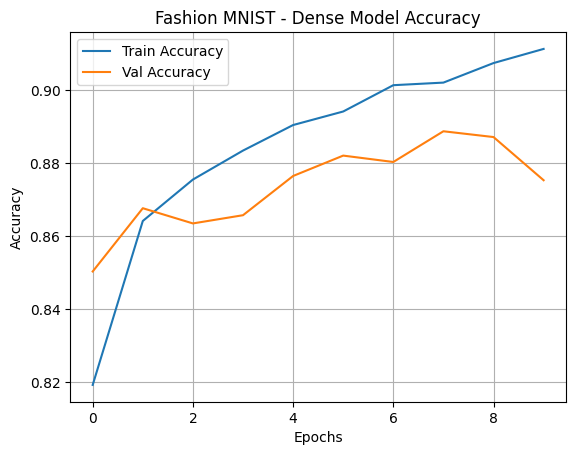

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Fashion MNIST - Dense Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
predictions = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
predicted_labels = np.argmax(predictions, axis=1)

In [ ]:
# Class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


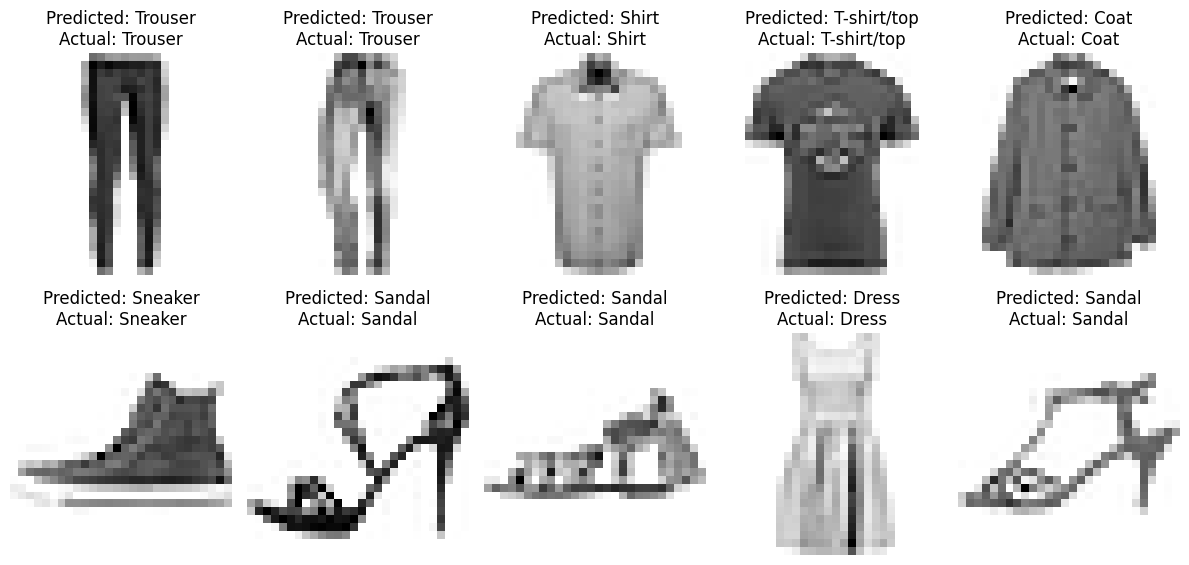

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(10):
    index = np.random.randint(0, len(x_test))
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[index], cmap='binary')
    plt.title(f"Predicted: {class_names[predicted_labels[index]]}\nActual: {class_names[y_test[index]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
#real time predictions
# Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Function to predict and show result
def predict_image(index):
    img = x_test[index]
    prediction = model.predict(img.reshape(1, 28, 28))
    predicted_class = np.argmax(prediction)

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {class_names[predicted_class]} | Actual: {class_names[y_test[index]]}")
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


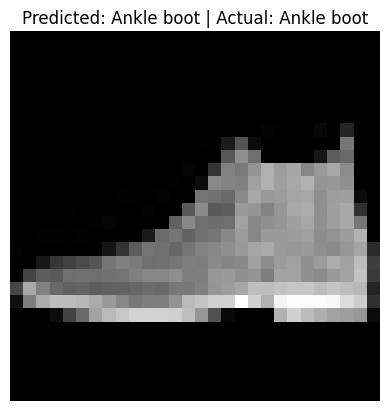

In [ ]:
predict_image(0)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


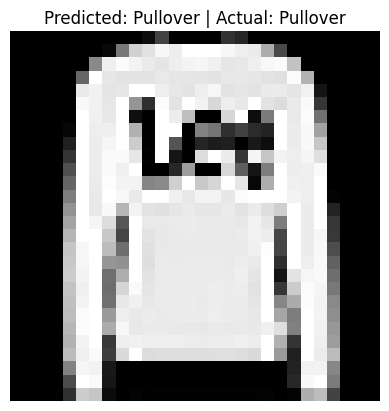

In [ ]:
predict_image(1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


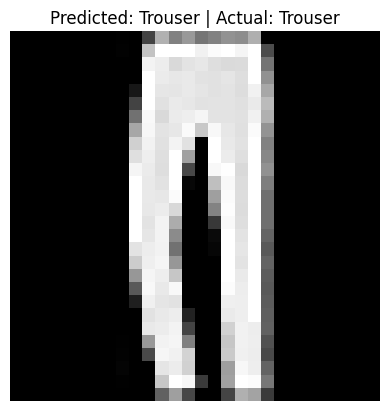

In [ ]:
predict_image(2)

# convolutional neural network

In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [ ]:
model1 = Sequential()
model1.add(Conv2D(64, (5, 5), activation='relu', padding='same', input_shape=(28, 28, 1)))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Conv2D(128, (5, 5), activation='relu', padding='same'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Conv2D(256, (5, 5), activation='relu', padding='same'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Flatten())
model1.add(Dense(256, activation='relu'))
model1.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model1.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.7691 - loss: 0.6143 - val_accuracy: 0.8834 - val_loss: 0.3131
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9002 - loss: 0.2700 - val_accuracy: 0.8994 - val_loss: 0.2720
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9215 - loss: 0.2136 - val_accuracy: 0.9104 - val_loss: 0.2453
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9328 - loss: 0.1800 - val_accuracy: 0.9122 - val_loss: 0.2528
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9446 - loss: 0.1483 - val_accuracy: 0.9235 - val_loss: 0.2306
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9538 - loss: 0.1230 - val_accuracy: 0.9165 - val_loss: 0.2669
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9613 - loss: 0.1005 - val_accuracy: 0.9164 - val_loss: 0.2760
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9689 - loss: 0.0810 - 

In [ ]:
test_loss, test_acc = model1.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9230 - loss: 0.3147
Test accuracy: 0.92


In [ ]:
train_loss, train_acc = model1.evaluate(x_train, y_train)
print(f"Train accuracy: {train_acc:.2f}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9805 - loss: 0.0517
Train accuracy: 0.98


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


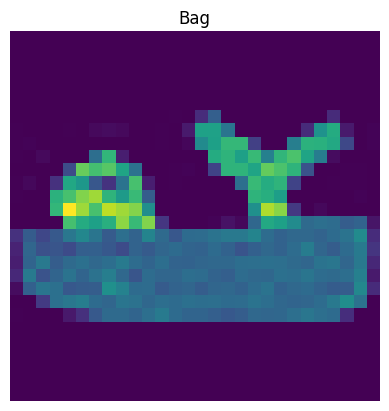

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def predict_fashion_mnist_image(image, model):
    # Ensure the image has the correct shape and data type for the CNN model
    image = image.reshape(1, 28, 28, 1).astype('float32') / 255.0
    prediction = model.predict(image)
    confidence = np.max(prediction)
    pred_label = np.argmax(prediction)
    labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

    # You can adjust this confidence threshold as needed
    if confidence < 0.5:
        return "Prediction confidence too low", confidence
    return labels[pred_label], confidence

# Select a random image from the test set
index = np.random.randint(0, len(x_test))
input_image = x_test[index]

# Get the prediction using the CNN model (model1)
prediction_result, confidence = predict_fashion_mnist_image(input_image, model1)

# Display the image and the prediction result
plt.imshow(input_image.reshape(28, 28), cmap='viridis')
if isinstance(prediction_result, str):
    plt.title(prediction_result)
else:
    plt.title(f"Predicted: {prediction_result} | Confidence: {confidence:.2f}")

plt.axis('off')
plt.show()